<a href="https://colab.research.google.com/github/leogemark-collab/DailyAchievement/blob/master/llorando_activity_02_data_analytics_programming.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import kagglehub
import os
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay

In [ ]:
path = kagglehub.dataset_download("danielcorredera/student-mat-csv")
print("Path to dataset files: ", path)

100%|██████████| 7.85k/7.85k [00:00<00:00, 9.59MB/s]

Extracting files...
Path to dataset files:  /root/.cache/kagglehub/datasets/danielcorredera/student-mat-csv/versions/1


In [ ]:
print(os.listdir(path))

['student-mat.csv']


In [ ]:
file_path = os.path.join(path, "student-mat.csv")
df = pd.read_csv(file_path, sep=";")


In [ ]:
df

,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,...,4,3,4,1,1,3,6,5,6,6
1,GP,F,17,U,GT3,T,1,1,at_home,other,...,5,3,3,1,1,3,4,5,5,6
2,GP,F,15,U,LE3,T,1,1,at_home,other,...,4,3,2,2,3,3,10,7,8,10
3,GP,F,15,U,GT3,T,4,2,health,services,...,3,2,2,1,1,5,2,15,14,15
4,GP,F,16,U,GT3,T,3,3,other,other,...,4,3,2,1,2,5,4,6,10,10
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
390,MS,M,20,U,LE3,A,2,2,services,services,...,5,5,4,4,5,4,11,9,9,9
391,MS,M,17,U,LE3,T,3,1,services,services,...,2,4,5,3,4,2,3,14,16,16
392,MS,M,21,R,GT3,T,1,1,other,other,...,5,5,3,3,3,3,3,10,8,7
393,MS,M,18,R,LE3,T,3,2,services,other,...,4,4,1,3,4,5,0,11,12,10


In [ ]:
df.head()

,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,...,4,3,4,1,1,3,6,5,6,6
1,GP,F,17,U,GT3,T,1,1,at_home,other,...,5,3,3,1,1,3,4,5,5,6
2,GP,F,15,U,LE3,T,1,1,at_home,other,...,4,3,2,2,3,3,10,7,8,10
3,GP,F,15,U,GT3,T,4,2,health,services,...,3,2,2,1,1,5,2,15,14,15
4,GP,F,16,U,GT3,T,3,3,other,other,...,4,3,2,1,2,5,4,6,10,10


In [ ]:
df.tail()

,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
390,MS,M,20,U,LE3,A,2,2,services,services,...,5,5,4,4,5,4,11,9,9,9
391,MS,M,17,U,LE3,T,3,1,services,services,...,2,4,5,3,4,2,3,14,16,16
392,MS,M,21,R,GT3,T,1,1,other,other,...,5,5,3,3,3,3,3,10,8,7
393,MS,M,18,R,LE3,T,3,2,services,other,...,4,4,1,3,4,5,0,11,12,10
394,MS,M,19,U,LE3,T,1,1,other,at_home,...,3,2,3,3,3,5,5,8,9,9


In [ ]:
print("Number of rows: ", df.shape[0])
print("Number of columns: ", df.shape[1])


Number of rows:  395
Number of columns:  33


In [ ]:
print(df.columns)

Index(['school', 'sex', 'age', 'address', 'famsize', 'Pstatus', 'Medu', 'Fedu',
       'Mjob', 'Fjob', 'reason', 'guardian', 'traveltime', 'studytime',
       'failures', 'schoolsup', 'famsup', 'paid', 'activities', 'nursery',
       'higher', 'internet', 'romantic', 'famrel', 'freetime', 'goout', 'Dalc',
       'Walc', 'health', 'absences', 'G1', 'G2', 'G3'],
      dtype='object')


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 395 entries, 0 to 394
Data columns (total 33 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   school      395 non-null    object
 1   sex         395 non-null    object
 2   age         395 non-null    int64 
 3   address     395 non-null    object
 4   famsize     395 non-null    object
 5   Pstatus     395 non-null    object
 6   Medu        395 non-null    int64 
 7   Fedu        395 non-null    int64 
 8   Mjob        395 non-null    object
 9   Fjob        395 non-null    object
 10  reason      395 non-null    object
 11  guardian    395 non-null    object
 12  traveltime  395 non-null    int64 
 13  studytime   395 non-null    int64 
 14  failures    395 non-null    int64 
 15  schoolsup   395 non-null    object
 16  famsup      395 non-null    object
 17  paid        395 non-null    object
 18  activities  395 non-null    object
 19  nursery     395 non-null    object
 20  higher    

In [ ]:
df.describe()

,age,Medu,Fedu,traveltime,studytime,failures,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
count,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000
mean,16.696203,2.749367,2.521519,1.448101,2.035443,0.334177,3.944304,3.235443,3.108861,1.481013,2.291139,3.554430,5.708861,10.908861,10.713924,10.415190
std,1.276043,1.094735,1.088201,0.697505,0.839240,0.743651,0.896659,0.998862,1.113278,0.890741,1.287897,1.390303,8.003096,3.319195,3.761505,4.581443
min,15.000000,0.000000,0.000000,1.000000,1.000000,0.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,3.000000,0.000000,0.000000
25%,16.000000,2.000000,2.000000,1.000000,1.000000,0.000000,4.000000,3.000000,2.000000,1.000000,1.000000,3.000000,0.000000,8.000000,9.000000,8.000000
50%,17.000000,3.000000,2.000000,1.000000,2.000000,0.000000,4.000000,3.000000,3.000000,1.000000,2.000000,4.000000,4.000000,11.000000,11.000000,11.000000
75%,18.000000,4.000000,3.000000,2.000000,2.000000,0.000000,5.000000,4.000000,4.000000,2.000000,3.000000,5.000000,8.000000,13.000000,13.000000,14.000000
max,22.000000,4.000000,4.000000,4.000000,4.000000,3.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,75.000000,19.000000,19.000000,20.000000


In [ ]:
print("Average final grade: ", df["G3"].mean())

Average final grade:  10.415189873417722


In [ ]:
print("Minimal final grade: ", df["G3"].min())
print("Maximum final grade: ", df["G3"].max())

Minimal final grade:  0
Maximum final grade:  20


In [ ]:
print(df["sex"].value_counts)

<bound method IndexOpsMixin.value_counts of 0      F
1      F
2      F
3      F
4      F
      ..
390    M
391    M
392    M
393    M
394    M
Name: sex, Length: 395, dtype: object>


In [ ]:
print(df["school"].value_counts)

<bound method IndexOpsMixin.value_counts of 0      GP
1      GP
2      GP
3      GP
4      GP
       ..
390    MS
391    MS
392    MS
393    MS
394    MS
Name: school, Length: 395, dtype: object>


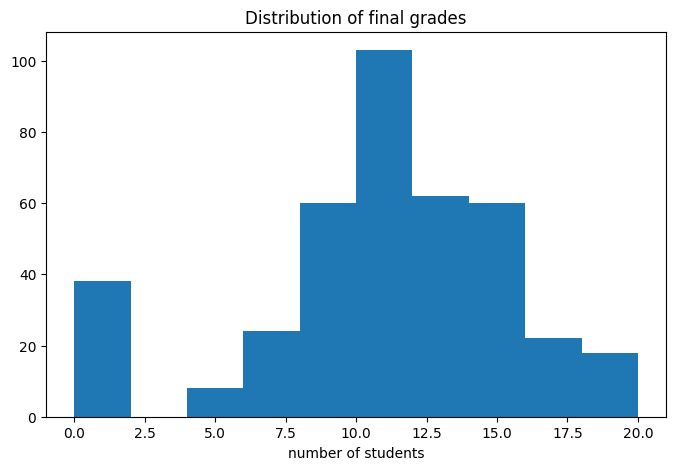

In [ ]:
plt.figure(figsize=(8,5))

plt.hist(df["G3"], bins=10)

plt.xlabel("final grade")
plt.xlabel("number of students")
plt.title("Distribution of final grades")

plt.show()


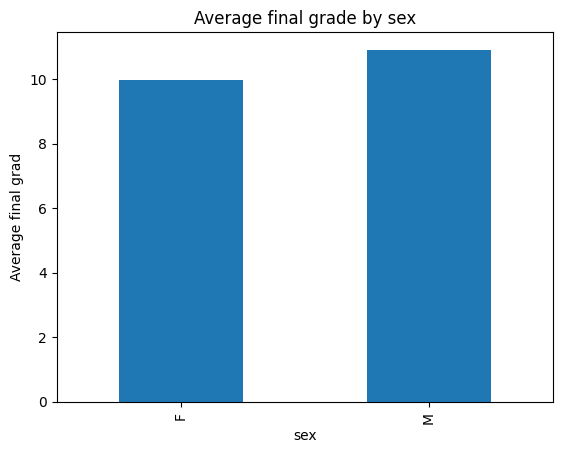

In [ ]:
df.groupby("sex")["G3"].mean().plot(kind="bar")

plt.xlabel("sex")
plt.ylabel("Average final grad")
plt.title("Average final grade by sex")

plt.show()

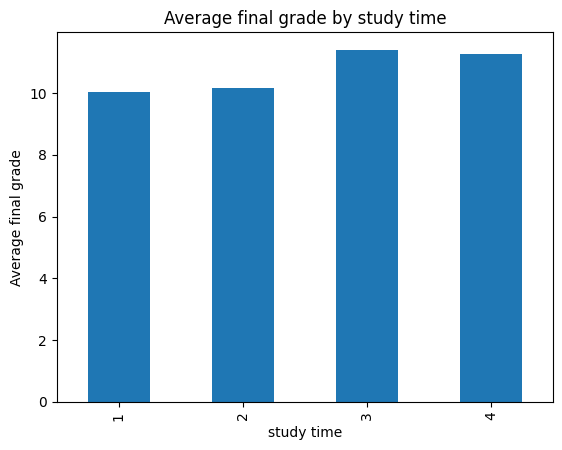

In [ ]:
df.groupby("studytime")["G3"].mean().plot(kind="bar")

plt.xlabel("study time")
plt.ylabel("Average final grade")
plt.title("Average final grade by study time")

plt.show()

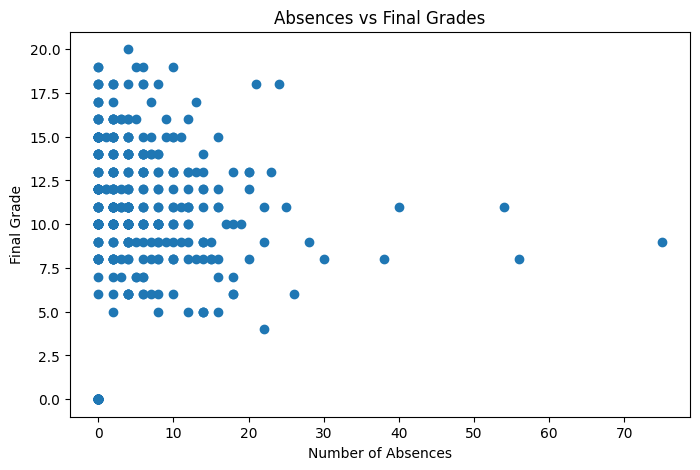

In [ ]:
plt.figure(figsize=(8,5))

plt.scatter(df["absences"], df["G3"])

plt.xlabel("Number of Absences")
plt.ylabel("Final Grade")
plt.title("Absences vs Final Grades")

plt.show()

In [ ]:
print(df["absences"].corr(df["G3"]))

0.03424731615006931


In [ ]:
df["pass"] = (df["G3"]>10).astype(int)

In [ ]:
print(df["pass"].value_counts())

pass
1    209
0    186
Name: count, dtype: int64


In [ ]:
features = [
    "age",
    "studytime",
    "failures",
    "G1",
    "G2"
]

x = df[features]
y = df["pass"]

In [ ]:
x_train, x_test, y_train, y_test = train_test_split(
    x,
    y,
    test_size=0.20,
    random_state=42,
    stratify =y,
)

In [ ]:
model = DecisionTreeClassifier(
    max_depth = 4,
random_state = 42,
)

model.fit(x_train, y_train)



DecisionTreeClassifier(max_depth=4, random_state=42)

In [ ]:
y_pred = model.predict(x_test)

print (y_pred)

[0 1 0 0 0 1 0 1 1 1 1 1 0 1 0 1 1 0 1 0 1 0 0 1 0 1 0 0 1 0 1 1 1 1 1 0 1
 1 0 0 1 1 0 0 1 0 1 1 1 0 1 0 1 1 0 0 1 0 1 1 0 0 0 0 0 1 0 0 1 1 0 1 1 0
 0 1 0 1 0]


In [ ]:
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy: ", accuracy)

Accuracy:  0.9620253164556962


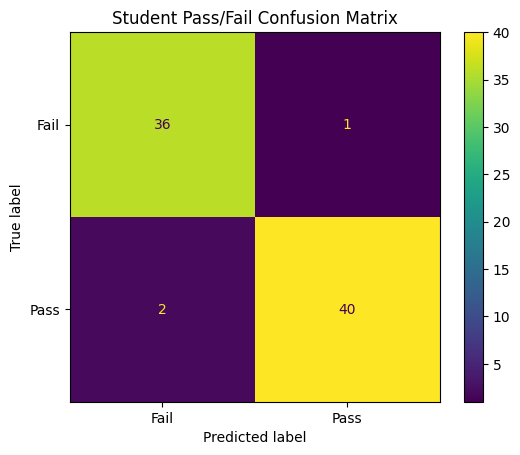

In [ ]:
cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels= ["Fail", "Pass"]
)

disp.plot()

plt.title ("Student Pass/Fail Confusion Matrix")
plt.show()

In [ ]:
results = x_test.copy()

results["Actual"] = y_test
results["Predicted"] = y_pred

results.head(10)

,age,studytime,failures,G1,G2,Actual,Predicted
259,17,4,0,10,9,0,0
230,17,2,0,13,13,1,1
387,19,3,1,7,5,0,0
134,15,2,0,9,0,0,0
81,15,3,0,11,10,1,0
5,16,2,0,15,15,1,1
219,17,3,0,9,10,0,0
372,17,3,0,13,11,1,1
282,18,4,0,12,12,1,1
112,16,2,1,10,13,1,1


In [ ]:
results["Risk"] = results["Predicted"].map({
    0: "At Risk",
    1: "Not at Risk"
})

results.head(10)

,age,studytime,failures,G1,G2,Actual,Predicted,Risk
259,17,4,0,10,9,0,0,At Risk
230,17,2,0,13,13,1,1,Not at Risk
387,19,3,1,7,5,0,0,At Risk
134,15,2,0,9,0,0,0,At Risk
81,15,3,0,11,10,1,0,At Risk
5,16,2,0,15,15,1,1,Not at Risk
219,17,3,0,9,10,0,0,At Risk
372,17,3,0,13,11,1,1,Not at Risk
282,18,4,0,12,12,1,1,Not at Risk
112,16,2,1,10,13,1,1,Not at Risk


In [ ]:
results["Recommendation"] = results["Predicted"].map({
    0: "Prioritizr for academic intervention",
    1: "Continue regular monitoring"
})

results.head(10)

,age,studytime,failures,G1,G2,Actual,Predicted,Risk,Recommendation
259,17,4,0,10,9,0,0,At Risk,Prioritizr for academic intervention
230,17,2,0,13,13,1,1,Not at Risk,Continue regular monitoring
387,19,3,1,7,5,0,0,At Risk,Prioritizr for academic intervention
134,15,2,0,9,0,0,0,At Risk,Prioritizr for academic intervention
81,15,3,0,11,10,1,0,At Risk,Prioritizr for academic intervention
5,16,2,0,15,15,1,1,Not at Risk,Continue regular monitoring
219,17,3,0,9,10,0,0,At Risk,Prioritizr for academic intervention
372,17,3,0,13,11,1,1,Not at Risk,Continue regular monitoring
282,18,4,0,12,12,1,1,Not at Risk,Continue regular monitoring
112,16,2,1,10,13,1,1,Not at Risk,Continue regular monitoring


In [ ]:
probabilities = model.predict_proba(x_test)

results["Probability_of_Failing"] = probabilities[:,0]

results.sort_values(
    "Probability_of_Failing",
    ascending=False

).head(20)

,age,studytime,failures,G1,G2,Actual,Predicted,Risk,Recommendation,Probability_of_Failing
130,15,3,2,12,0,0,0,At Risk,Prioritizr for academic intervention,1.000000
134,15,2,0,9,0,0,0,At Risk,Prioritizr for academic intervention,0.989474
387,19,3,1,7,5,0,0,At Risk,Prioritizr for academic intervention,0.989474
193,16,1,0,8,9,0,0,At Risk,Prioritizr for academic intervention,0.989474
330,18,4,0,9,8,0,0,At Risk,Prioritizr for academic intervention,0.989474
170,16,1,2,6,5,0,0,At Risk,Prioritizr for academic intervention,0.989474
390,20,2,2,9,9,0,0,At Risk,Prioritizr for academic intervention,0.989474
394,19,1,0,8,9,0,0,At Risk,Prioritizr for academic intervention,0.989474
144,17,1,3,5,0,0,0,At Risk,Prioritizr for academic intervention,0.989474
352,18,1,1,8,7,0,0,At Risk,Prioritizr for academic intervention,0.989474


In [ ]:
priority_students = results.sort_values(
    "Probability_of_Failing",
    ascending=False
).head(20)

priority_students



,age,studytime,failures,G1,G2,Actual,Predicted,Risk,Recommendation,Probability_of_Failing
130,15,3,2,12,0,0,0,At Risk,Prioritizr for academic intervention,1.000000
134,15,2,0,9,0,0,0,At Risk,Prioritizr for academic intervention,0.989474
387,19,3,1,7,5,0,0,At Risk,Prioritizr for academic intervention,0.989474
193,16,1,0,8,9,0,0,At Risk,Prioritizr for academic intervention,0.989474
330,18,4,0,9,8,0,0,At Risk,Prioritizr for academic intervention,0.989474
170,16,1,2,6,5,0,0,At Risk,Prioritizr for academic intervention,0.989474
390,20,2,2,9,9,0,0,At Risk,Prioritizr for academic intervention,0.989474
394,19,1,0,8,9,0,0,At Risk,Prioritizr for academic intervention,0.989474
144,17,1,3,5,0,0,0,At Risk,Prioritizr for academic intervention,0.989474
352,18,1,1,8,7,0,0,At Risk,Prioritizr for academic intervention,0.989474
